In [2]:
import pandas as pd

# Carrega a base consolidada limpa
df = pd.read_csv('../data/sim_campinas_consolidado.csv', low_memory=False)

print(f"📊 Total de linhas carregadas: {len(df)}")
print("\n=== DISTRIBUIÇÃO COMPLETA DA COLUNA SEXO ===")
print(df['SEXO_NOME'].value_counts(dropna=False))

📊 Total de linhas carregadas: 53110

=== DISTRIBUIÇÃO COMPLETA DA COLUNA SEXO ===
SEXO_NOME
Masculino                 28175
Feminino                  24918
Ignorado/Não informado       17
Name: count, dtype: int64


=== DISTRIBUIÇÃO DA ESCOLARIDADE ===
ESCOLARIDADE
Ignorado                          21659
Fundamental I (1ª a 4ª série)      9901
Ensino Médio                       6679
Fundamental II (5ª a 8ª série)     4863
Ensino Superior Completo           4477
Ignorado/Sem informação            2680
Sem escolaridade                   2153
Ensino Superior Incompleto          698
Name: count, dtype: int64


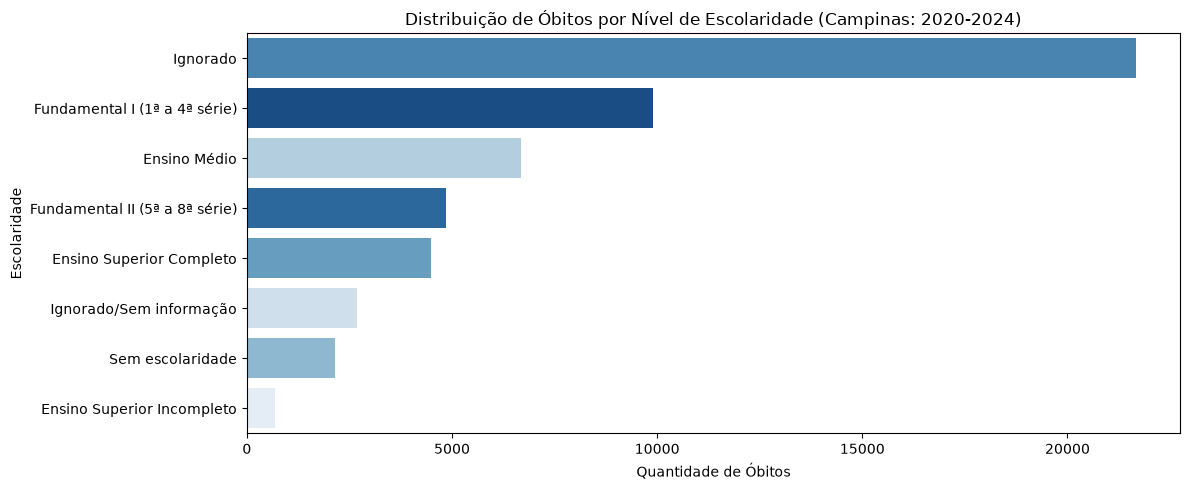

In [3]:
# Contagem detalhada da escolaridade na base consolidada
print("=== DISTRIBUIÇÃO DA ESCOLARIDADE ===")
print(df['ESCOLARIDADE'].value_counts(dropna=False))

# Gráfico de barras da escolaridade
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.countplot(data=df, y='ESCOLARIDADE', order=df['ESCOLARIDADE'].value_counts().index, palette='Blues_r', hue='ESCOLARIDADE', legend=False)
plt.title('Distribuição de Óbitos por Nível de Escolaridade (Campinas: 2020-2024)', fontsize=12)
plt.xlabel('Quantidade de Óbitos')
plt.ylabel('Escolaridade')
plt.tight_layout()
plt.show()

📊 Total de registros válidos para 2020: 8589

=== DISTRIBUIÇÃO DA ESCOLARIDADE EM 2020 ===
ESCOLARIDADE
Ignorado                          4921
Fundamental I (1ª a 4ª série)      965
Ignorado/Sem informação            845
Ensino Médio                       611
Ensino Superior Completo           581
Fundamental II (5ª a 8ª série)     427
Sem escolaridade                   168
Ensino Superior Incompleto          71
Name: count, dtype: int64


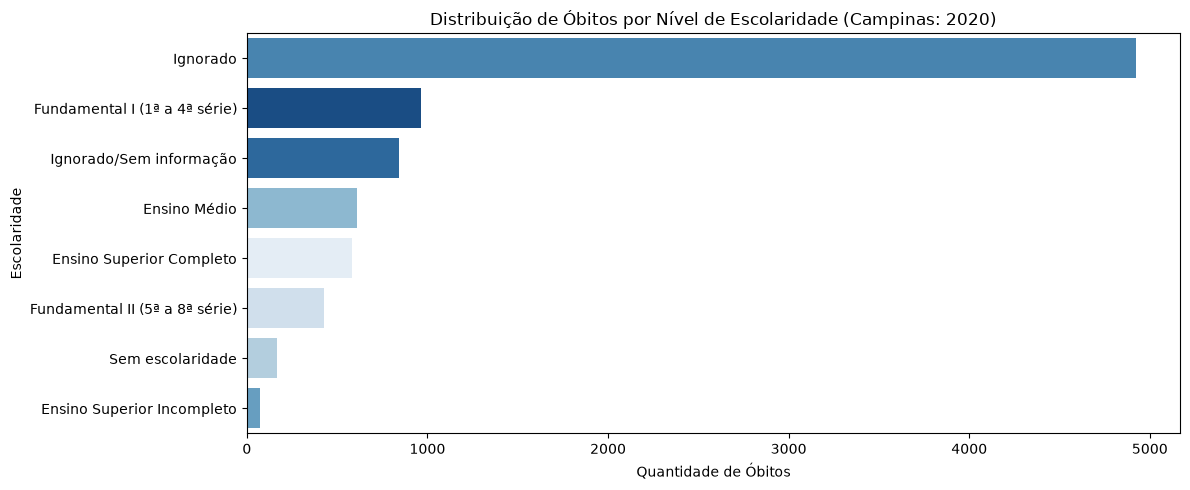

In [4]:
# Filtra apenas os registros do ano de 2020
df_2020 = df[df['ANO_OBITO'] == 2020]

print(f"📊 Total de registros válidos para 2020: {len(df_2020)}")
print("\n=== DISTRIBUIÇÃO DA ESCOLARIDADE EM 2020 ===")
print(df_2020['ESCOLARIDADE'].value_counts(dropna=False))

# Gráfico de barras da escolaridade para 2020
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.countplot(
    data=df_2020, 
    y='ESCOLARIDADE', 
    order=df_2020['ESCOLARIDADE'].value_counts().index, 
    palette='Blues_r', 
    hue='ESCOLARIDADE', 
    legend=False
)
plt.title('Distribuição de Óbitos por Nível de Escolaridade (Campinas: 2020)', fontsize=12)
plt.xlabel('Quantidade de Óbitos')
plt.ylabel('Escolaridade')
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
df_2020_raw = pd.read_csv('../data/sim_campinas_2020.csv', dtype=str, low_memory=False)

# Procura colunas que contenham "CEP" ou "POS" no nome
colunas_cep = [c for c in df_2020_raw.columns if 'CEP' in c or 'POS' in c]
print("Colunas encontradas com CEP/POS:", colunas_cep)

Colunas encontradas com CEP/POS: ['TPPOS']


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega a base consolidada limpa
df = pd.read_csv('../data/sim_campinas_consolidado.csv', low_memory=False)

print(f"Total de registros carregados para análise espacial: {len(df)}")

# Verifica se existe coluna de município ou dados de localização adicionais
print("\nAmostra dos códigos de município de residência:")
print(df['CODMUNRES'].value_counts().head())

Total de registros carregados para análise espacial: 53110

Amostra dos códigos de município de residência:
CODMUNRES
350950    45877
355240     1152
351907      935
353650      500
355620      362
Name: count, dtype: int64


In [8]:
import pandas as pd
df_2020_raw = pd.read_csv('../data/sim_campinas_2020.csv', dtype=str, low_memory=False)

# Procura colunas relacionadas a endereço, logradouro ou bairro (corrigido)
colunas_texto = [c for c in df_2020_raw.columns if any(termo in c for termo in ['END', 'BAIRR', 'LOGR', 'DISTR'])]
print("Colunas de texto/localização encontradas:", colunas_texto)

Colunas de texto/localização encontradas: []
